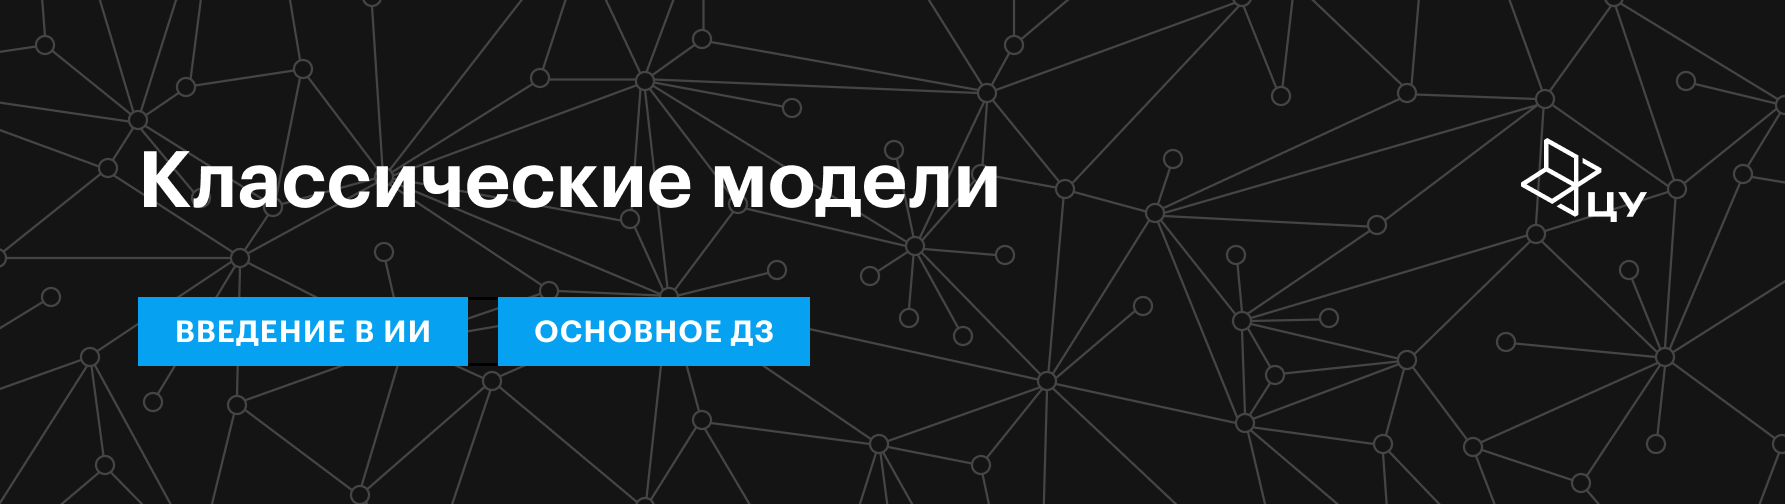

# Домашнее задание по теме «ML-модели»

В этом задании ты потренируешься реализовывать пайплайн обучения  ML-моделей. В задании приветствуются размышления, выдвижение предположений и изложение собственных мыслей.

> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Визуализации обязательны.
>
> 7. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
>
> 8. Оформляй все выводы (портрет банка, портрет клиента, бизнес-решение) в markdown-тексте.
>
> 9. Фиксируй random_state для воспроизводимости результатов.


## Легенда

Ты претендуешь на позицию главного аналитика небольшого банка.

Предыдущего аналитика уличили в мошеннической схеме и выгнали с позором. Его работа привела банк к финансовым проблемам, поэтому тебе доверили заняться оптимизацией выдачи кредитов — ещё не успели посвятить в тонкости дел, но работы уже подкинули.

Твоя задача — быстро разобраться в данных, найти закономерности и предложить несколько ML-моделей, которые могут ускорить принятие решений. От того, как хорошо ты справишься, зависит твоё будущее и будущее банка. О подробностях задания — читай ниже. Удачи!



## О датасете

Банк предоставил датасет, который содержит исторические данные по заявкам на кредит и результатам его выдачи.

Целевая переменная: `Loan_Status` — выдаст банк клиенту кредит или нет.
* `Y` — кредит погашен / проблем не было.  
* `N` — кредит проблемный / невозврат.

* `Loan_ID` — идентификатор заявки.
* `Gender` — пол заявителя (`Male` — мужчина, `Female` — женщина).
* `Married` — семейное положение (`Yes` — состоит в браке, `No` — не состоит).
* `Dependents` — количество иждивенцев у заявителя (`0`, `1`, `2`, `3+` — три и более).
* `Education` — уровень образования (`Graduate` — есть высшее/оконченное образование, `Not Graduate` — нет).
* `Self_Employed` — занятость (`Yes` — самозанятый/предприниматель, `No` — работает по найму или не относится к самозанятым).
* `ApplicantIncome` — доход основного заявителя.
* `CoapplicantIncome` — доход созаёмщика (если созаёмщика нет, часто стоит `0`).
* `LoanAmount` — сумма кредита, которую запрашивает клиент (в условных единицах датасета).
* `Loan_Amount_Term` — срок кредита в днях.
* `Credit_History` — показатель кредитной истории (`1` — кредитная история есть и/или считается «хорошей», `0` — кредитной истории нет и/или она «плохая»).
* `Property_Area` — тип местности проживания (`Urban` — город, `Semiurban` — пригород/полугородская зона, `Rural` — сельская местность).



## Задание 1 [4 балла]

Проведи EDA. Эта часть домашнего задания проверит твои аналитические навыки.

1) Найди зависимости между признаками **[1 балл].**
2) Найди корреляции или зависимости с целевой переменной **[1 балл].**
3) Подготовь данные к четвёртому пункту задания — обработай пропуски и предобработай категориальные признаки **[1 балл].**
4) На основе датасета опиши самые значимые и характерные признаки, приведи ключевые статистики и сделай выводы о природе поведения — составь портреты **[1 балл]:**
    - банка,
    - типичного «хорошего» клиента — того, кому выдавали кредит,
    - типичного «плохого» клиента — того, кому не выдавали кредит.

К каждому пункту задания добавь:

- не менее одной иллюстрации или графика;
- не менее одного вывода. В выводах должен быть развёрнутый ответ с твоими мыслями, а не сухие факты.

В задании приветствуется творческий подход — запись промежуточных выводов:
- по графикам;
- посчитанным значениям;
- стратегии заполнения пропусков и так далее.

In [1]:
# @title
import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# @title
!gdown 1hEQp8v8xUSTnNyZjiY7pGZvmzfczib19
df = pd.read_csv("dataset.csv")

Downloading...
From: https://drive.google.com/uc?id=1hEQp8v8xUSTnNyZjiY7pGZvmzfczib19
To: /content/dataset.csv
100% 38.0k/38.0k [00:00<00:00, 46.6MB/s]


### **1. Зависимости между признаками.**

Вообще говоря, не очень понятно, как именно мы можем утверждать о конкретных зависимостях, тем не меее приведем некоторые соображения:
1. У мужчин число иждевенцев больше, чем у женщин;
2. Горожане имеют больший доход, чем сельчане.
3. Женатые (замужние) заемщики имеют больший доход созаемщика и сумму кредита;
4. Заемщики с большим доходом занимают большие суммы;
5. Заемщики с высшим образованием имеют больший доход;
6. Самозанятые / предприниматели имеют больший доход;
7. Чаще всего кредит берут на полгода (180 дней) или полгода (360 дней)
8. Чем больше срок кредита, тем больше сумма заема;
9. Заемщики с лучшей кредитной историей чаще берут займы.


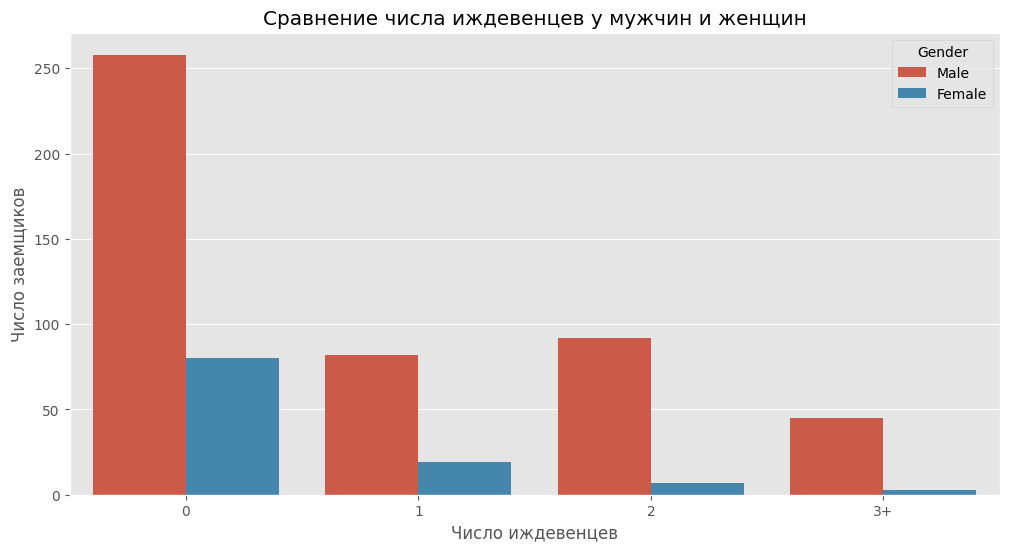

In [3]:
# @title
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Dependents", hue="Gender")
plt.title("Сравнение числа иждевенцев у мужчин и женщин")
plt.ylabel("Число заемщиков")
plt.xlabel("Число иждевенцев")
plt.show()

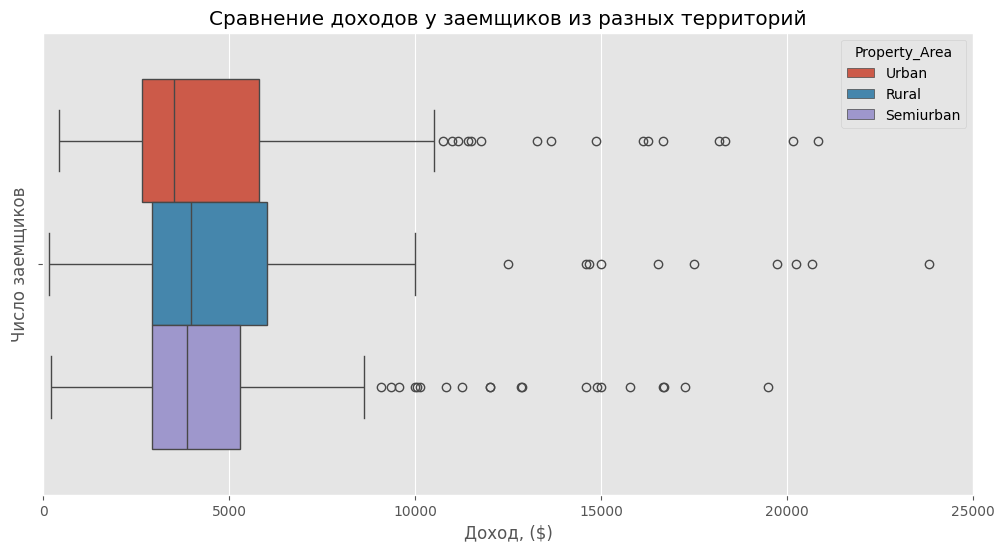

In [4]:
# @title
plt.figure(figsize=(12, 6))
plt.xlim(0, 25_000)
sns.boxplot(data=df, x="ApplicantIncome", hue="Property_Area")
plt.title("Сравнение доходов у заемщиков из разных территорий")
plt.ylabel("Число заемщиков")
plt.xlabel("Доход, ($)")
plt.show()

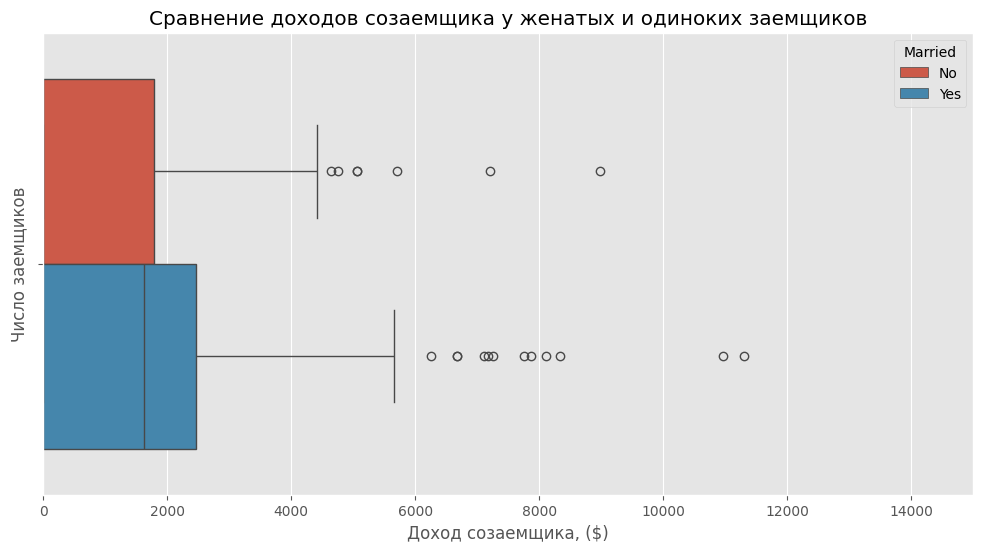

In [5]:
# @title
plt.figure(figsize=(12, 6))
plt.xlim(0, 15_000)
sns.boxplot(data=df, x="CoapplicantIncome", hue="Married")
plt.title("Сравнение доходов созаемщика у женатых и одиноких заемщиков")
plt.ylabel("Число заемщиков")
plt.xlabel("Доход созаемщика, ($)")
plt.show()

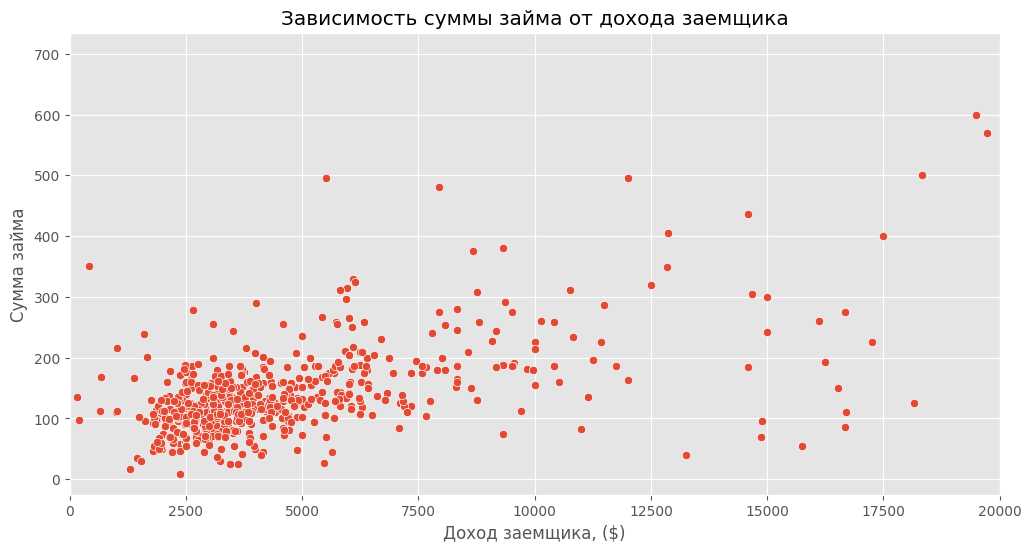

In [6]:
# @title
plt.figure(figsize=(12, 6))
plt.xlim(0, 20_000)
sns.scatterplot(data=df, x="ApplicantIncome", y="LoanAmount")
plt.title("Зависимость суммы займа от дохода заемщика")
plt.ylabel("Сумма займа")
plt.xlabel("Доход заемщика, ($)")
plt.show()

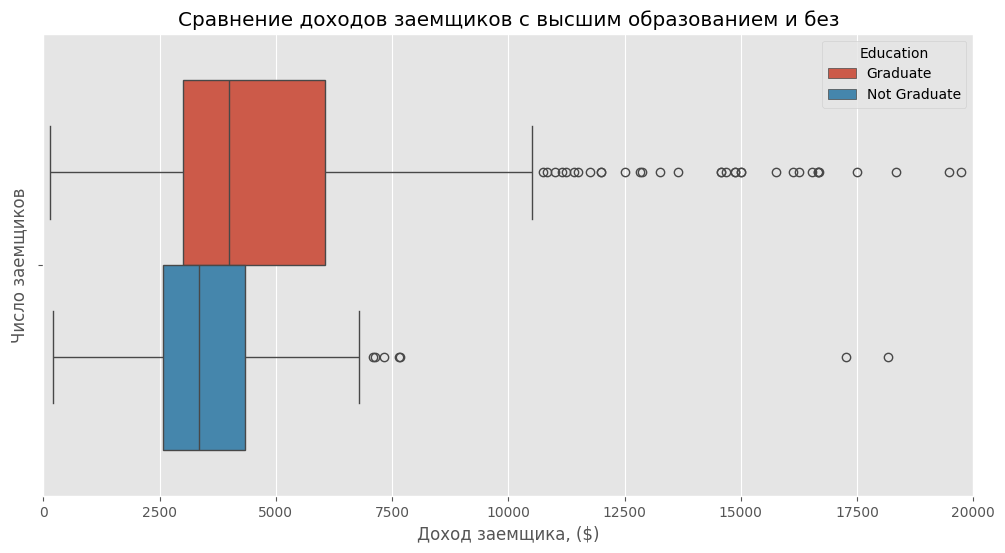

In [7]:
# @title
plt.figure(figsize=(12, 6))
plt.xlim(0, 20_000)
sns.boxplot(data=df, x="ApplicantIncome", hue="Education")
plt.title("Сравнение доходов заемщиков с высшим образованием и без")
plt.ylabel("Число заемщиков")
plt.xlabel("Доход заемщика, ($)")
plt.show()

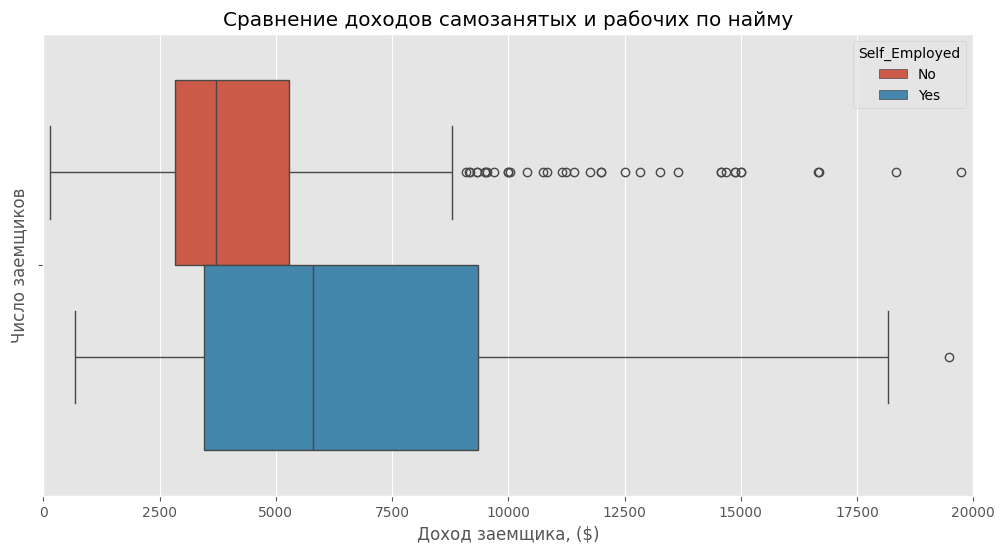

In [8]:
# @title
plt.figure(figsize=(12, 6))
plt.xlim(0, 20_000)
sns.boxplot(data=df, x="ApplicantIncome", hue="Self_Employed")
plt.title("Сравнение доходов самозанятых и рабочих по найму")
plt.ylabel("Число заемщиков")
plt.xlabel("Доход заемщика, ($)")
plt.show()

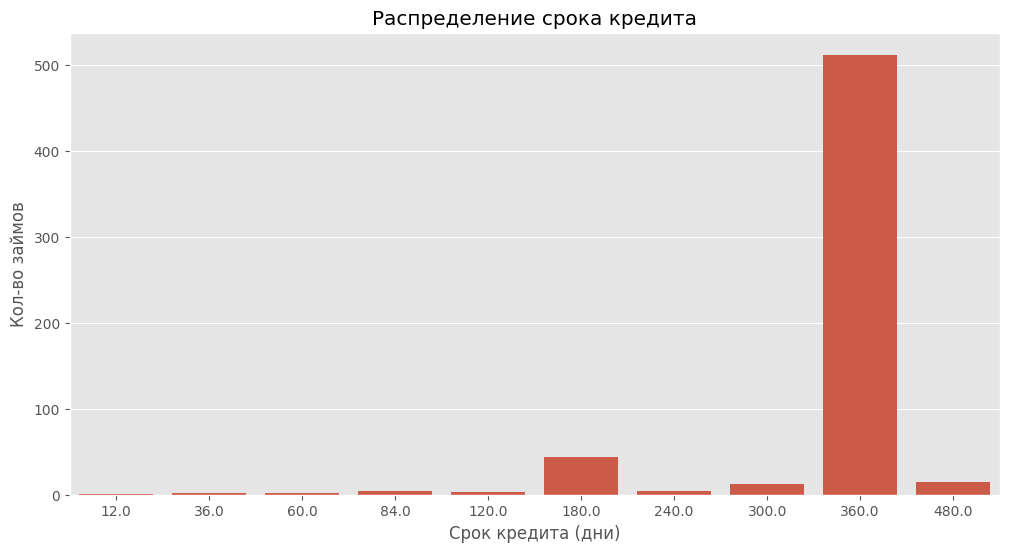

In [9]:
# @title
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Loan_Amount_Term")
plt.title("Распределение срока кредита")
plt.ylabel("Кол-во займов")
plt.xlabel("Срок кредита (дни)")
plt.show()

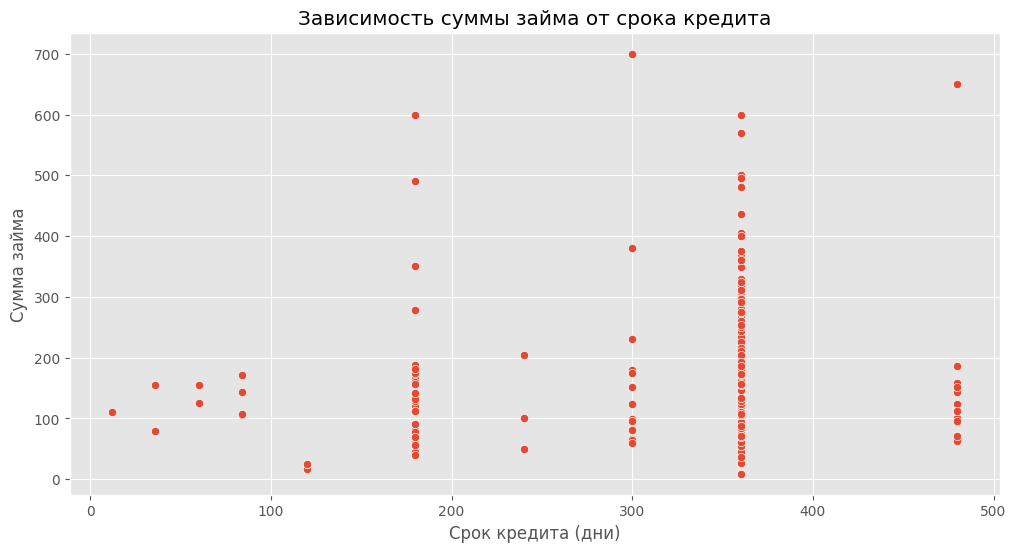

In [10]:
# @title
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="Loan_Amount_Term", y="LoanAmount")
plt.title("Зависимость суммы займа от срока кредита")
plt.ylabel("Сумма займа")
plt.xlabel("Срок кредита (дни)")
plt.show()

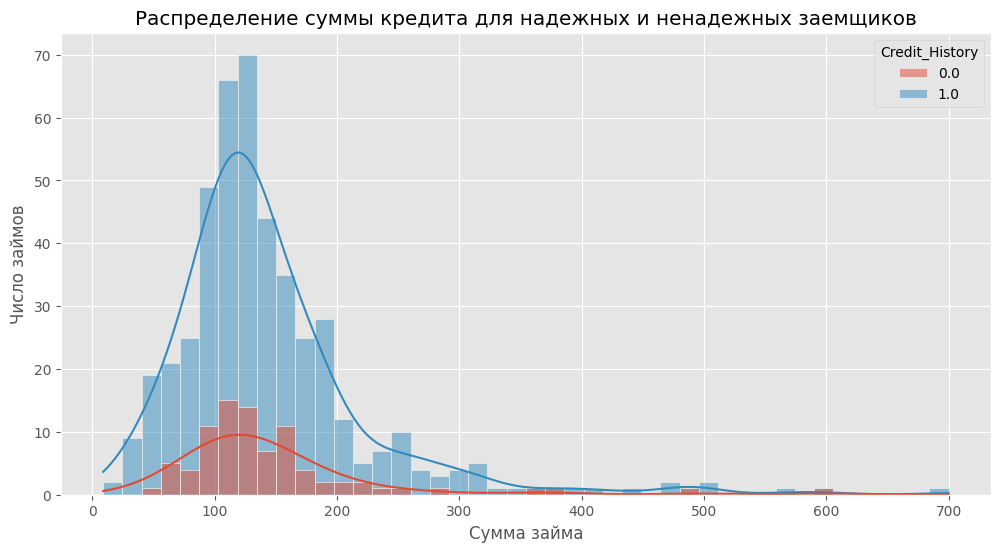

In [11]:
# @title
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="LoanAmount", hue="Credit_History", kde=True)
plt.title("Распределение суммы кредита для надежных и ненадежных заемщиков")
plt.ylabel("Число займов")
plt.xlabel("Сумма займа")
plt.show()

Из приведенных выше графиков, очевидно, список зависимостей сократится:
Вообще говоря, не очень понятно, как именно мы можем утверждать о конкретных зависимостях, тем не меее приведем некоторые соображения:
1. У мужчин число иждевенцев больше, чем у женщин;
2. Горожане имеют больший доход, чем сельчане.
3. Заемщики с высшим образованием имеют больший доход;
4. Самозанятые / предприниматели имеют больший доход;
5. Чаще всего кредит берут на полгода (180 дней) или полгода (360 дней)
6. Заемщики с лучшей кредитной историей чаще берут займы.


### **2. Корелляции с целовой переменной**

In [12]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [14]:
# @title
df_encoded = df.set_index("Loan_ID")
df_encoded = pd.get_dummies(
  df,
  columns=["Gender", "Married", "Property_Area", "Education", "Self_Employed"],
  drop_first=True
)
df_encoded["Dependents"] = df_encoded["Dependents"].map({"0": 0, "1": 1, "2": 2, "3+": 3})
df_encoded["Loan_Status"] = df_encoded["Loan_Status"].map({"N": 0, "Y": 1})

In [15]:
df_encoded.corr(numeric_only=True)["Loan_Status"].sort_values()

,Loan_Status
Education_Not Graduate,-0.085884
CoapplicantIncome,-0.059187
Property_Area_Urban,-0.043621
LoanAmount,-0.037318
Loan_Amount_Term,-0.021268
ApplicantIncome,-0.004710
Self_Employed_Yes,-0.003700
Dependents,0.006781
Gender_Male,0.025407
Married_Yes,0.084281


Как нетрудно заметить, наиболее существенная положителньая корреляция с целевой переменной наблюдается у признаков `Credit History` и `Propetry Area`, а именно такая: жителям пригородов чаще выдает кредиты.

Кроме того наиболее сильная отрицательная корреляция наблюдается у параметра `Education`: людям без обрзаования чаще отказывают в займе.

### **3. Подготовка данных**

Часть этого пункта мы выполнили ранее, с помощью `OHE`, а также кастомного маппинга. Осталось обработать пропуски:
- `Dependents` по умолчанию считаем, что заемщик не заполнил эту графу, а значит таковых нет, т.е. таковых 0
- `Loan Amount` дозаполним медианой
- `Loan Amount Term` аналогично, поскольку значения целые
- `Credit History` по умолчанию (нулевая гипотеза), считаем кредитную историю слабой, т.е. 0

In [16]:
# @title
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Dependents               599 non-null    float64
 2   ApplicantIncome          614 non-null    int64  
 3   CoapplicantIncome        614 non-null    float64
 4   LoanAmount               592 non-null    float64
 5   Loan_Amount_Term         600 non-null    float64
 6   Credit_History           564 non-null    float64
 7   Loan_Status              614 non-null    int64  
 8   Gender_Male              614 non-null    bool   
 9   Married_Yes              614 non-null    bool   
 10  Property_Area_Semiurban  614 non-null    bool   
 11  Property_Area_Urban      614 non-null    bool   
 12  Education_Not Graduate   614 non-null    bool   
 13  Self_Employed_Yes        614 non-null    bool   
dtypes: bool(6), float64(5), in

In [17]:
# @title
df_encoded = df_encoded.set_index("Loan_ID")
df_encoded["Dependents"] = df_encoded["Dependents"].fillna(0)
df_encoded["LoanAmount"] = df_encoded["LoanAmount"].fillna(df_encoded["LoanAmount"].median())
df_encoded["Loan_Amount_Term"] = df_encoded["Loan_Amount_Term"].fillna(df_encoded["Loan_Amount_Term"].median())
df_encoded["Credit_History"] = df_encoded["Credit_History"].fillna(0)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, LP001002 to LP002990
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dependents               614 non-null    float64
 1   ApplicantIncome          614 non-null    int64  
 2   CoapplicantIncome        614 non-null    float64
 3   LoanAmount               614 non-null    float64
 4   Loan_Amount_Term         614 non-null    float64
 5   Credit_History           614 non-null    float64
 6   Loan_Status              614 non-null    int64  
 7   Gender_Male              614 non-null    bool   
 8   Married_Yes              614 non-null    bool   
 9   Property_Area_Semiurban  614 non-null    bool   
 10  Property_Area_Urban      614 non-null    bool   
 11  Education_Not Graduate   614 non-null    bool   
 12  Self_Employed_Yes        614 non-null    bool   
dtypes: bool(6), float64(5), int64(2)
memory usage: 42.0+ KB


### **4. Конечные выводы**

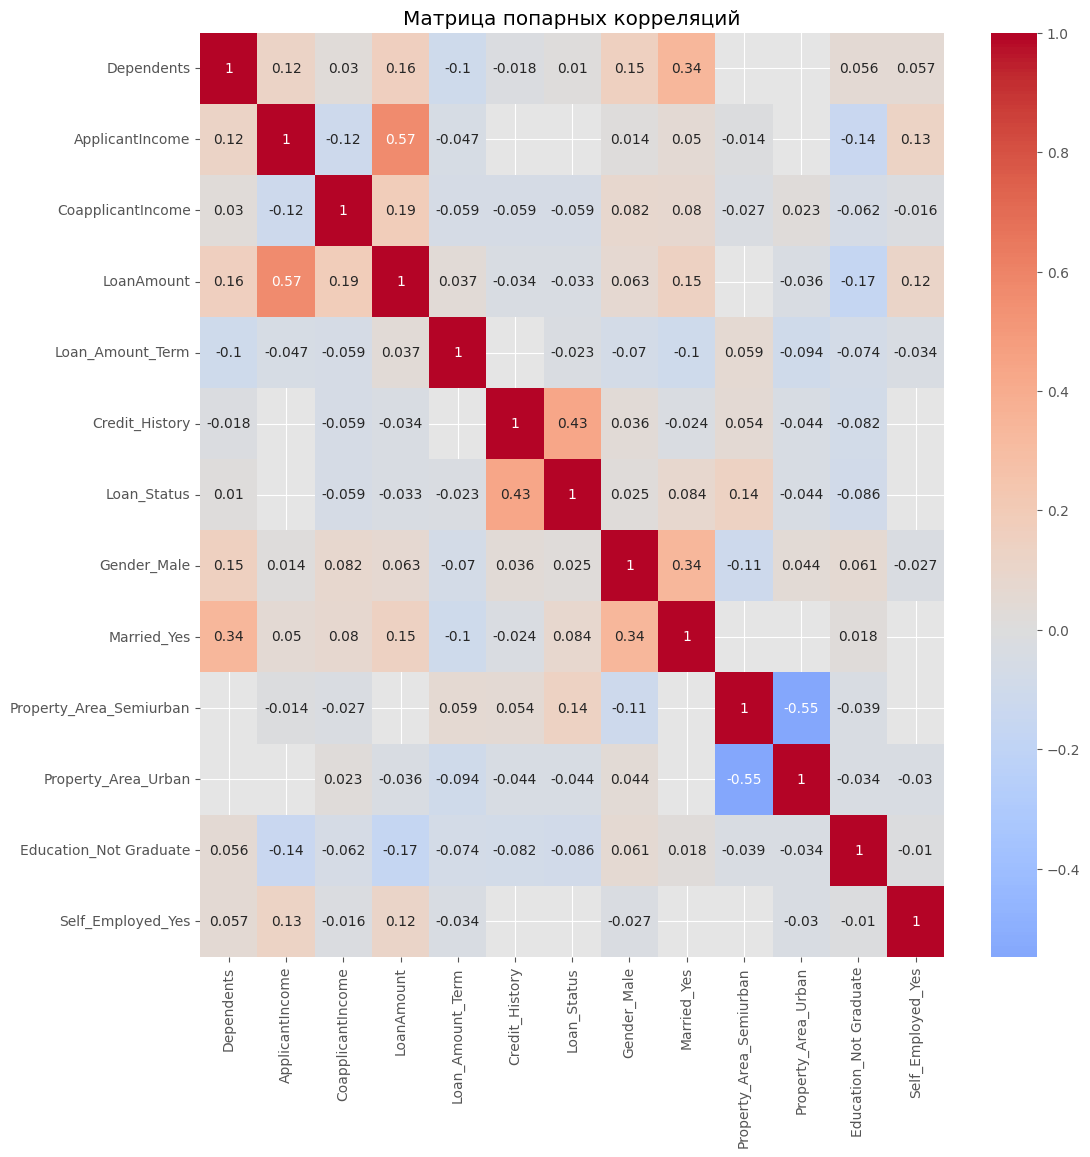

In [18]:
# @title
plt.figure(figsize=(12, 12))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix[np.abs(corr_matrix) > 0.01], annot=True, cmap='coolwarm', center=0)
plt.title("Матрица попарных корреляций")
plt.show()

<Figure size 640x480 with 0 Axes>

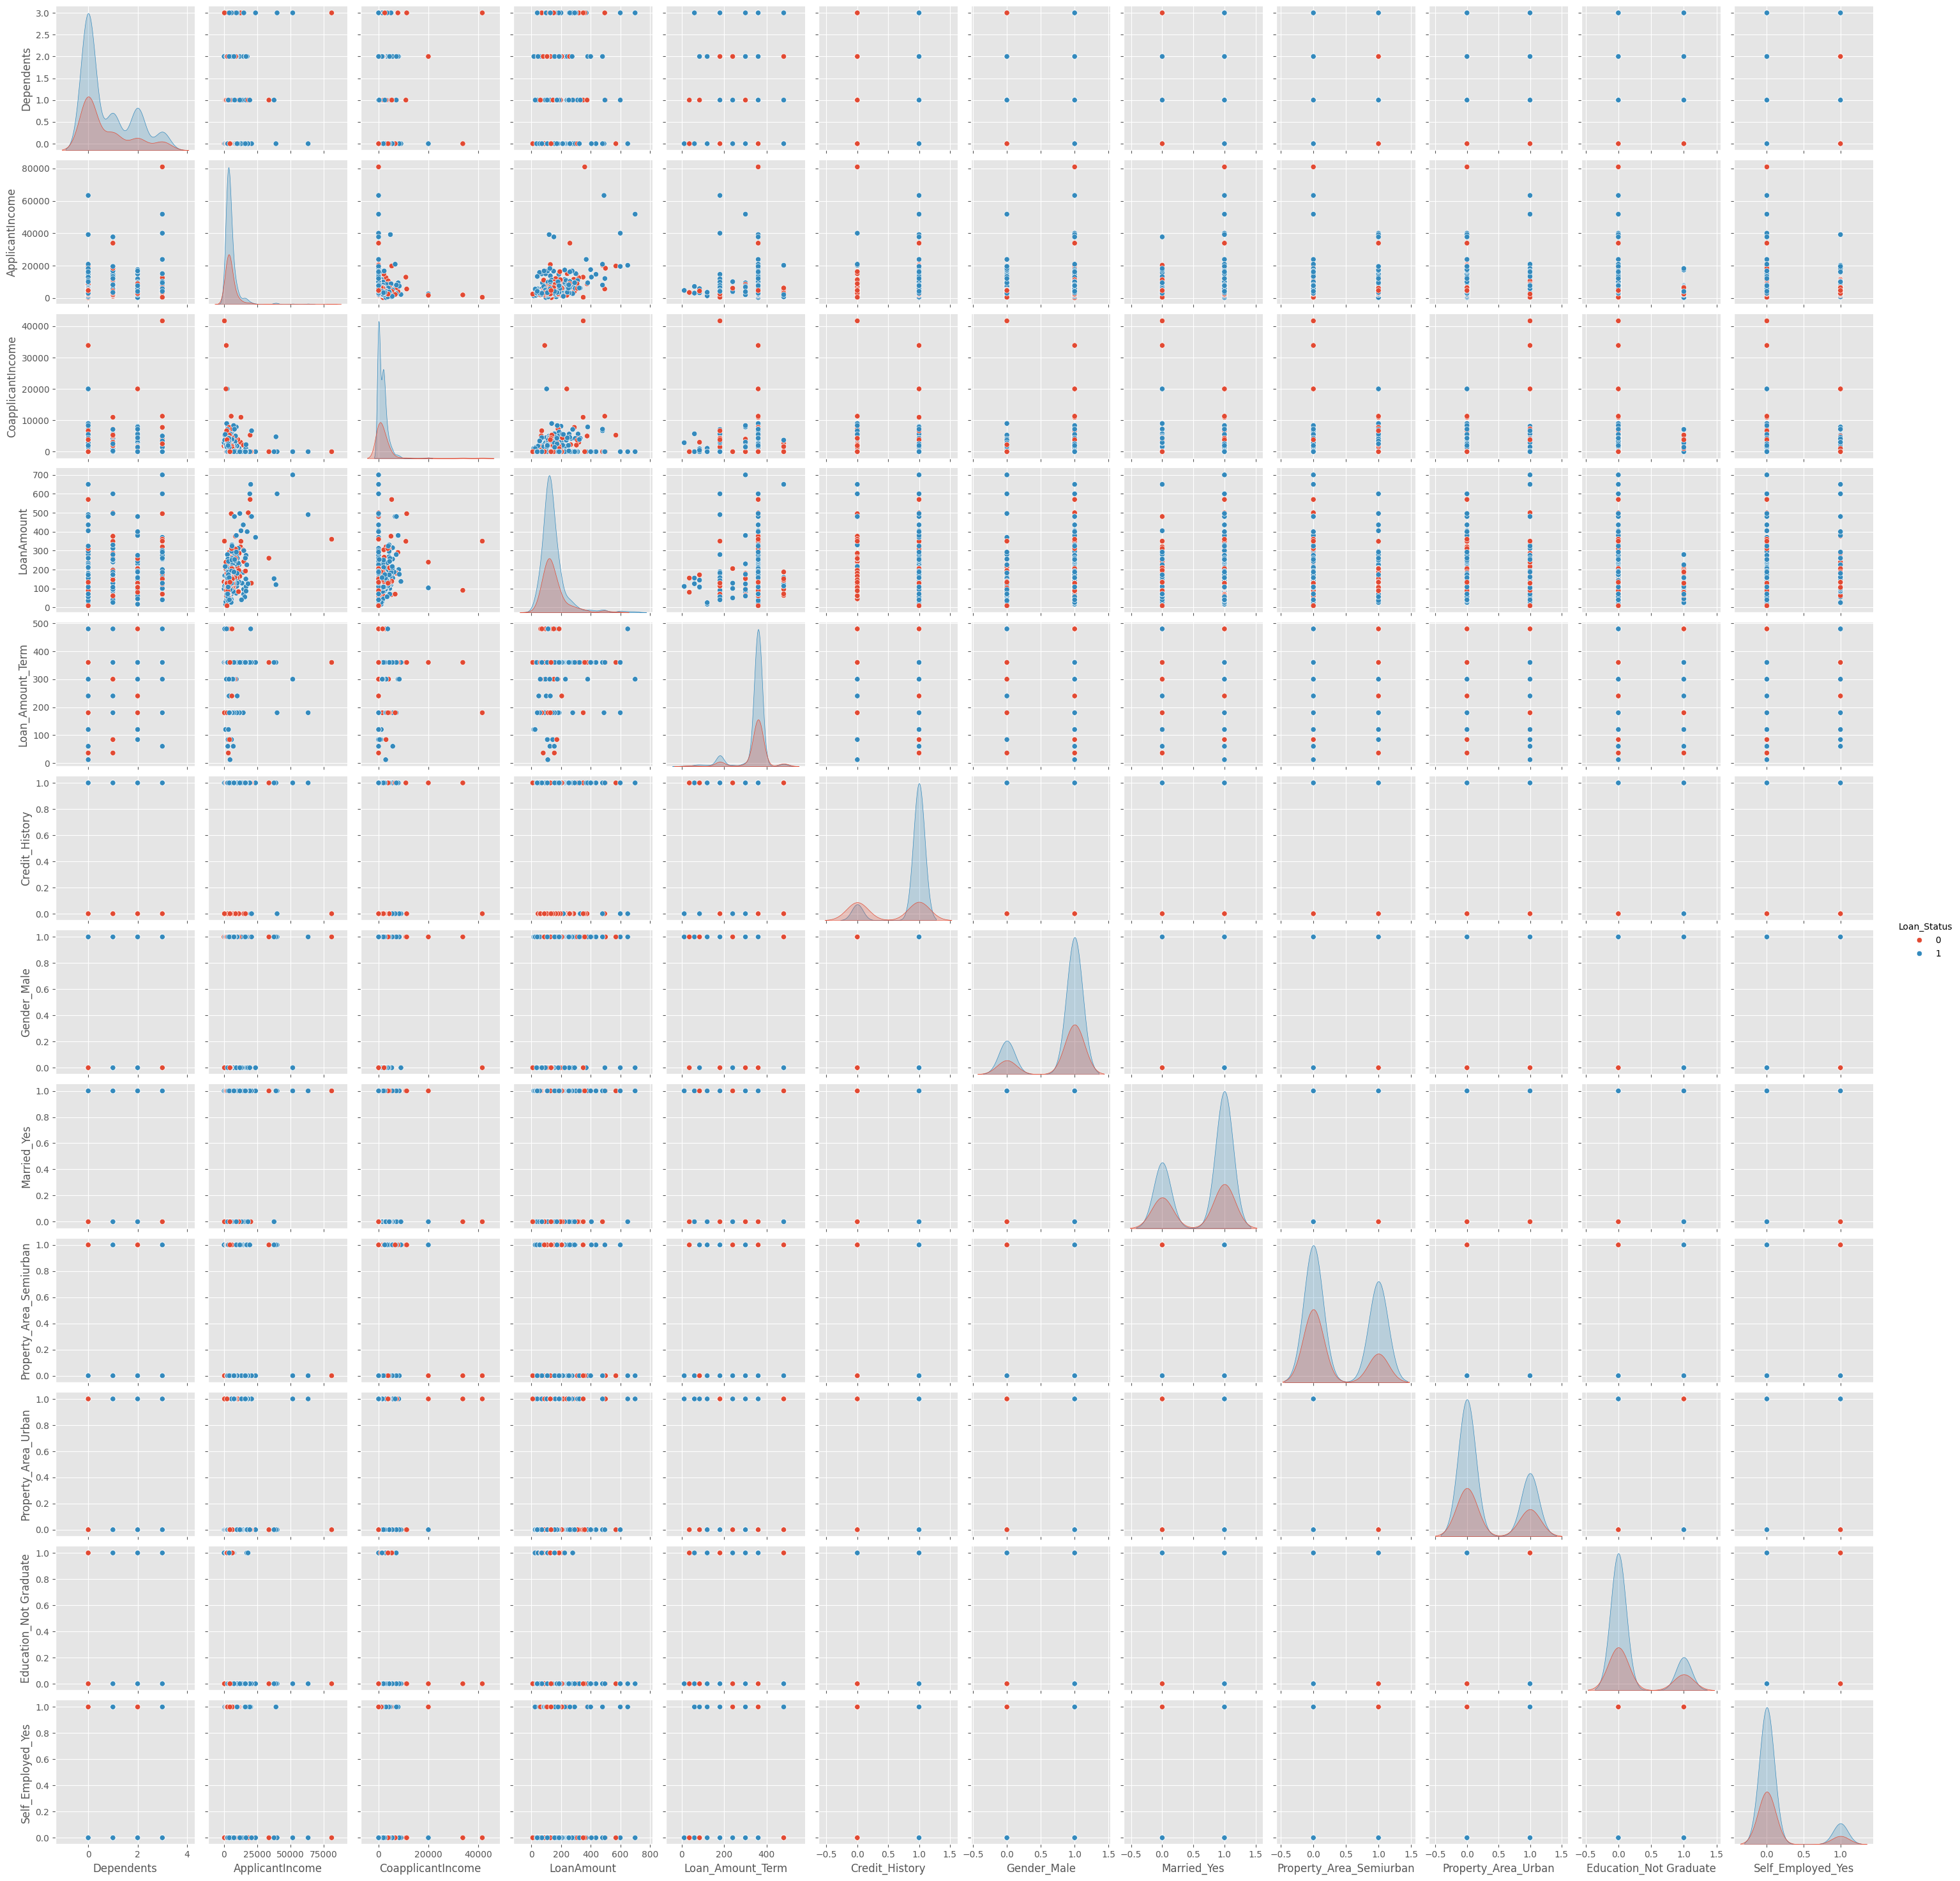

In [19]:
# @title
plt.suptitle("Попарные зависимости признаков")
sns.pairplot(data=df_encoded, hue="Loan_Status")
plt.show()

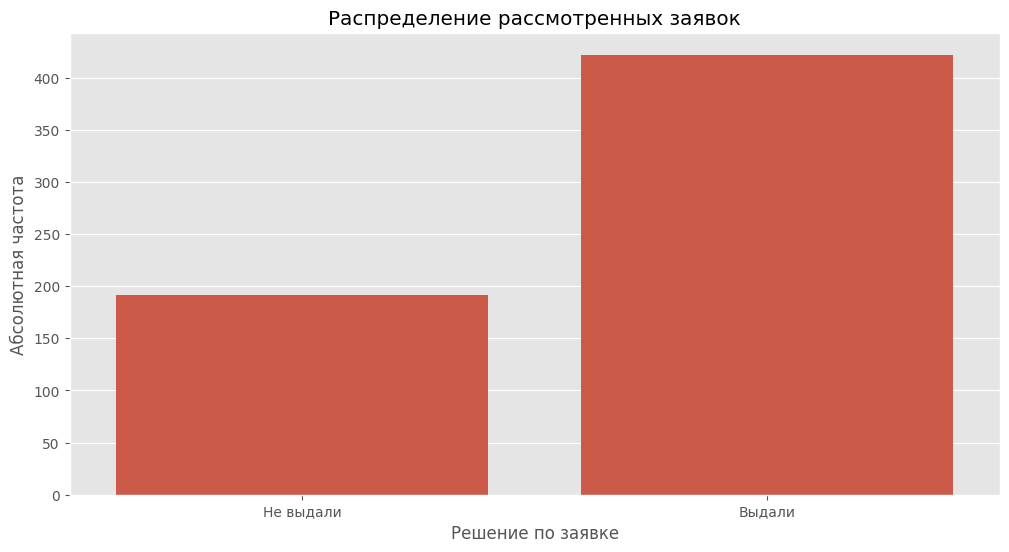

In [20]:
# @title
plt.figure(figsize=(12, 6))
plt.title("Распределение рассмотренных заявок")
sns.countplot(data=df_encoded, x="Loan_Status")
plt.xticks([0, 1], ["Не выдали", "Выдали"])
plt.xlabel("Решение по заявке")
plt.ylabel("Абсолютная частота")
plt.show()

Исхожя из всего, что было сказано и проиллюстрировано выше, можно составить следующие портреты:
* Банк: выдает кредиты чаще, чем не выдает, можно сказать, "щедрый".
* "Хороший" клиент:
  - Имеет высшее образование
  - Имеет хотя одного иждивенца (жену)
  - Хорошая кредитная история
  - Живет в пригороде

  В общем, простой такой работяга (представитель рабочего класса)
* "Плохой" клиент:
  - Не имеет высшего образования
  - Живет в городе
  
  "Неустроившийся" горожанин

## Задание 2 [6 баллов]

<!--На данный момент у банка небольшие финансовые трудности, поэтому руководство думает над следующими стратегиями выхода из кризиса:

### Новые горизонты

Можно рискнуть и начать активно выдавать кредиты желающим его взять.

* **Цель:** найти как можно больше людей, способных закрыть свой долг с процентами

* **Ограничение:** не менее трети людей из тех, кому мы одобрили кредит, должны на самом деле смочь его выплатить (финансисты рассчитали, что это - точка безубыточности)

### Жесткая экономия

Можно наоборот, свернуть активное кредитование и выдавать кредит только "надежным" людям

* **Цель:** минимизировать долю людей, которым мы выдали кредит, но которые не смогли его выплатить

* **Ограничение:** не менее 80% людей из тех, кому мы одобрили кредит, должны на самом деле смочь его выплатить

**От вас требуется:**
1) Построить ML модели, удовлетворяющие данным требованиям
2) Оформить блок кода, позволяющий ввести вручную данные о заемщике и получить ответ, одобрила бы модель ему кредит или нет (руководство хочет лично оценить модели).


**Формальные требования:**

1) Построить не менее 2-х моделей на стратегию "Новые горизонты" **[2.5 балла]**

2) Построить не менее 2-х моделей на стратегию "Жёсткая экономия" **[2.5 балла]**

3) Сравнить построенные модели между собой. Выбрать лучшую и пояснить, почему была выбрана именно она (Precision, Recall, Accuracy, интерпретируемость и т.п) Очень важно писать развернутые выводы и свои мысли! **[1 балл]**
 -->

Построй модели и проведи анализ.

1) Построй не менее двух моделей для стратегии «Новые горизонты» **[2 балла]**.

2) Построй не менее двух моделей для стратегии «Жёсткая экономия» **[2 балла]**.

3) Сравни построенные модели между собой. Выбери лучшую и поясни своё решение с опорой на показатели. Например, Precision, Recall, Accuracy, интерпретируемость и тому подобное. Обязательно фиксируй свои мысли и развёрнутые выводы **[1 балл]**.

4) Оформи блок кода, позволяющий ввести данные заявителя вручную и получить ответ: одобрила бы модель кредит или нет (руководство хочет оценить модели лично) **[1 балл]**.

#### Описание задания

У банка финансовые трудности, поэтому руководство думает над двумя стратегиями выхода из кризиса.

| Стратегия  | Описание | Цель | Ограничение |            
|----------------|----------------------------|---------------------------------|-------------------------------|
| «Новые горизонты» | Рискнуть, и начать активно выдавать кредиты всем, <br>кто хочет их получить | Найти как можно больше людей,<br> способных закрыть свой долг с процентами | Не менее трети из тех, кто получил одобрение кредита, <br>должны в итоге его выплатить. Финансисты рассчитали, <br>что это точка безубыточности|
| «Жёсткая экономия» | Свернуть активное кредитование<br> и выдавать кредит только «надёжным» людям    | Минимизировать долю тех людей,<br> кто получил кредит, но не смог его выплатить | Не менее 80% людей из тех, кому банк одобрил <br>кредит, должны реально его выплатить |


In [21]:
# @title
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score

In [22]:
X = df_encoded.drop(columns="Loan_Status")
y = df_encoded["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Перефразируем условие на матрицу ошибок:
|   | P  | N
|---|---|---|
|T  | Кредит был одобрен надежному заемщику  | Кредит не был одобрен надежному заемщику  |
|F  | Кредит был одобрен ненадженому заемщику  | Кредит не был одобрен ненадженому заемщику  |

### **1. "Новые горизонты"**

Исходя из предыдущей матрицы, можем сделать вывод, что условие:
> Не менее трети из тех, кто получил одобрение кредита, должны в итоге его выплатить. Финансисты рассчитали, что это точка безубыточности

Есть условие на отношение: $\frac{TP}{TP+FP}=precision\ge1/3\iff TP\ge \frac{1}{2}FP$

Если интерпретировать, то на каждый второй неправильно выданный займ, должен приходится как минимум один возвращенный.

При этом условии мы хотим максимизировать число $TP+FP$, т.е. общую долю выданных кредитов. Очевидно, это можно легко сделать с помощью `trashhold`:

In [23]:
def predict_with_thresholds(pred, t):
  return (pred[:, 1] >= t).astype(int)

In [24]:
model_lr = LogisticRegression(max_iter=1000, n_jobs=-1)
model_rf = RandomForestClassifier(random_state=42, max_depth=20, min_samples_leaf=5)

model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

pred_proba_lr = model_lr.predict_proba(X_test)
pred_proba_rf = model_rf.predict_proba(X_test)

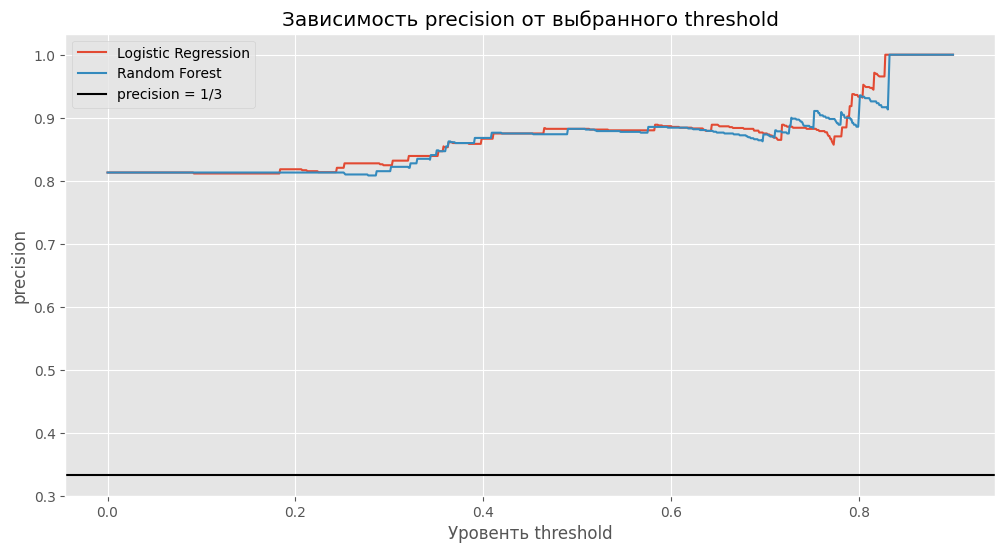

In [25]:
# @title
thresholds = np.linspace(0, 0.9, 1000) # Увелечение до 1 подикнет кучу варнингов, т.к. ни один элемент не выбрерется

plt.figure(figsize=(12, 6))
plt.title("Зависимость precision от выбранного threshold")
plt.xlabel("Уровенть threshold")
plt.ylabel("precision")

sns.lineplot(x=thresholds, y=[precision_score(y_test, predict_with_thresholds(pred_proba_lr, t)) for t in thresholds], label="Logistic Regression")
sns.lineplot(x=thresholds, y=[precision_score(y_test, predict_with_thresholds(pred_proba_rf, t)) for t in thresholds], label="Random Forest")
plt.axhline(1 / 3, color="black", label="precision = 1/3")

plt.legend()

plt.show()

Как видно из графика, какую бы модель мы не взяли и какой бы порог мы не выбрали, выполняется условие на `precision`, поэтому чтобы максимизировать число выданных кредитов, выберем порог $0,2$ для Logistic Regression и $0,3$ для Random Forest - на порогах ниже мы не получаем статистически оценимых результатов.

### **2. "Жесткая экономия"**

Исходя из предыдущей матрицы, можем сделать вывод, что условие:

> Не менее 80% людей из тех, кому банк одобрил
кредит, должны реально его выплатить

Есть условие на отношение: $\frac{TP}{TP+FP}=precision\ge80\%\iff TP\ge 4FP$

Если интерпретировать, то на каждый правильно выданный займ, должно приходится не более 4-х один невозвращенных.

При этом условии мы хотим минимизировать число $\frac{FP}{TP+FP}=1-\underbrace{precision}_{\ge 0,8}\le 0,2$ - автоматически выполнятеся при достигнутом `precision`


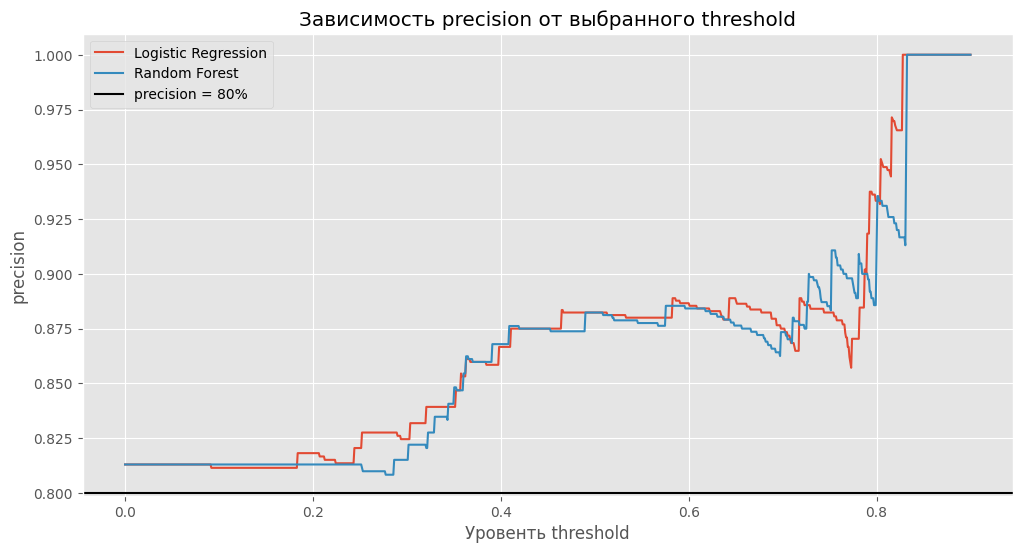

In [26]:
# @title
thresholds = np.linspace(0, 0.9, 1000) # Увелечение до 1 подикнет кучу варнингов, т.к. ни один элемент не выбрерется

plt.figure(figsize=(12, 6))
plt.title("Зависимость precision от выбранного threshold")
plt.xlabel("Уровенть threshold")
plt.ylabel("precision")

sns.lineplot(x=thresholds, y=[precision_score(y_test, predict_with_thresholds(pred_proba_lr, t)) for t in thresholds], label="Logistic Regression")
sns.lineplot(x=thresholds, y=[precision_score(y_test, predict_with_thresholds(pred_proba_rf, t)) for t in thresholds], label="Random Forest")
plt.axhline(0.8, color="black", label="precision = 80%")

plt.legend()

plt.show()

In [27]:
# @title
print(f"LR: {thresholds[np.argmax([precision_score(y_test, predict_with_thresholds(pred_proba_lr, t)) for t in thresholds])]}")
print(f"RF: {thresholds[np.argmax([precision_score(y_test, predict_with_thresholds(pred_proba_rf, t)) for t in thresholds])]}")

LR: 0.8279279279279279
RF: 0.8324324324324325


Пиковое значение по обоим параметрам достигается при `threshold = 0.834` для RandomForest и `threshold = 0.759` для Logistic Regression.

### **3. Выбор финальной модели**

In [28]:
# @title
from sklearn.metrics import classification_report

print(classification_report(y_test, predict_with_thresholds(pred_proba_lr, 0.2)))
print(classification_report(y_test, predict_with_thresholds(pred_proba_rf, 0.3)))

print(classification_report(y_test, predict_with_thresholds(pred_proba_lr, 0.759)))
print(classification_report(y_test, predict_with_thresholds(pred_proba_rf, 0.834)))

              precision    recall  f1-score   support

           0       0.50      0.04      0.08        23
           1       0.82      0.99      0.90       100

    accuracy                           0.81       123
   macro avg       0.66      0.52      0.49       123
weighted avg       0.76      0.81      0.74       123

              precision    recall  f1-score   support

           0       0.25      0.04      0.07        23
           1       0.82      0.97      0.89       100

    accuracy                           0.80       123
   macro avg       0.53      0.51      0.48       123
weighted avg       0.71      0.80      0.73       123

              precision    recall  f1-score   support

           0       0.26      0.65      0.38        23
           1       0.88      0.58      0.70       100

    accuracy                           0.59       123
   macro avg       0.57      0.62      0.54       123
weighted avg       0.76      0.59      0.64       123

              preci

Заметим, что классы не сбалансированы: зачастую в таких случаях выбор стоит основывать на `f1-score`, но давайте последовательно:
- Очевидно в колонке `precision` мы не найдем ничего интересного, поскольку специально подрабирали параметры
- `recall` для нулевого класса (отказ в кредитовании) выглядит катастрофически плохо: мы почти всегда неверно его угадываем, по сравнению с классом 1, т.е. статистически всегда выдаем больше, что впрочем соответствует ТЗ. Для 3-4 модели это показатель ведет себя более сдержанно.
- `f1-score` - среднее гармоническое, объединяет оба параметра и именно по нему будем выбирать финальную модель. Смотрим на строку `weighted avg` - взвешенное среднее, поскольку классы, опять же, несбаланисрованны. Лучше всех этот параметр у модели линеной регрессии с порогом $\approx0.759$

In [29]:
final_threshold = 0.7594594594594595

### **4. Финальная модель**

In [30]:
# @title
import warnings
warnings.filterwarnings("ignore", message=".*feature names.*")


def predict(customer):
  return predict_with_thresholds(model_lr.predict_proba(customer), final_threshold)

location = int(input("Где живет заемщик? (1 - город, 2 - пригород, 3 - сельская местность): "))

customer = np.array([
  int(input("Введите кол-во иждевенцев у заемщика (0 - 0, 1 - 1, 2 - 2, 3+ - 3): ")),
  int(input("Введите доход заемщика: ")),
  int(input("Введите доход созаемщика: ")),
  int(input("Введите сумму займа: ")),
  int(input("Введите срок кредита (в днях): ")),
  float(input("Введите кредтную историю клиента (0 - плохая, 1 - хорошая): ")),
  int(input("Введите пол заемщика (0 - женщина, 1 - мужчина): ")),
  int(input("Введите семейное положение заемщика (0 - свободен, 1 - женат / замужем): ")),
  int(location == 2),
  int(location == 1),
  int(input("Есть ли у заемщика высшее образование (0 - нет, 1 - да): ")),
  int(input("Работает ли заемщик 'на себя' (0 - нет, 1 - да): ")),
]).reshape(1, -1)
print("Да, можно выдать кредит" if predict(customer)[0] else "Нет, нельзя выдавать кредит, ненадежный заемщик")

Где живет заемщик? (1 - город, 2 - пригород, 3 - сельская местность): 2
Введите кол-во иждевенцев у заемщика (0 - 0, 1 - 1, 2 - 2, 3+ - 3): 2
Введите доход заемщика: 10000
Введите доход созаемщика: 100
Введите сумму займа: 1000
Введите срок кредита (в днях): 360
Введите кредтную историю клиента (0 - плохая, 1 - хорошая): 1
Введите пол заемщика (0 - женщина, 1 - мужчина): 1
Введите семейное положение заемщика (0 - свободен, 1 - женат / замужем): 1
Есть ли у заемщика высшее образование (0 - нет, 1 - да): 1
Работает ли заемщик 'на себя' (0 - нет, 1 - да): 0
Нет, нельзя выдавать кредит, ненадежный заемщик
